# Generative Adversarial Network (GAN) on MNIST

This notebook demonstrates how to build an image generation model from scratch using the MNIST handwritten digits dataset and PyTorch. We will construct a **Generator** to create handwritten digits from random noise and a **Discriminator** to distinguish between real MNIST images and the fake images produced by the Generator.

## 1. Import Required Libraries

We import PyTorch for building the neural networks, `torchvision` for downloading and processing the MNIST dataset, and `matplotlib` for visualizing the generated results.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducibility (optional)
torch.manual_seed(42)

## 2. Device Configuration

We automatically select the available device. If a CUDA-enabled GPU is available on the machine, we will use it to significantly speed up training. Otherwise, we seamlessly fall back to the CPU.

In [2]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Load and Preprocess the MNIST Dataset

We use `torchvision.datasets` to download MNIST. The images are automatically converted to PyTorch tensors. We also normalize the pixel values to the range `[-1, 1]` because the Generator will use a `Tanh` activation function in its final layer (which outputs values between -1 and 1).

We create a `DataLoader` to efficiently load the data into memory in batches, which prevents out-of-memory errors and keeps training smooth.

Shape of batch images: torch.Size([128, 1, 28, 28])


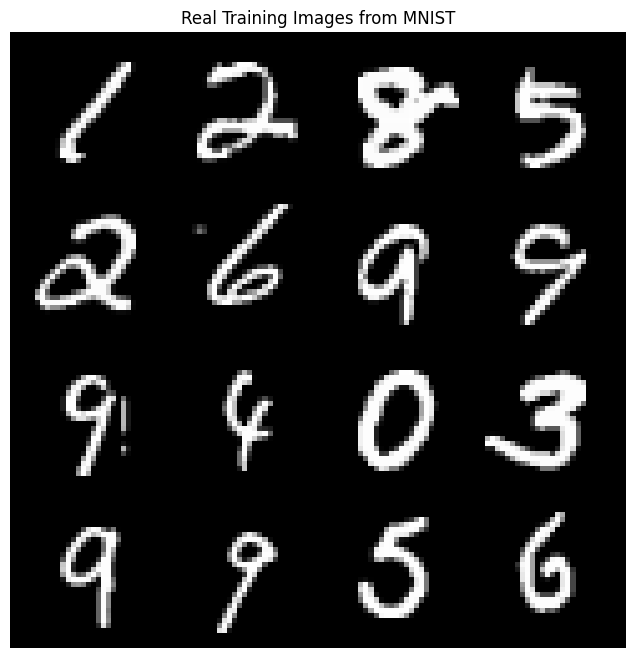

In [3]:
batch_size = 128

# Transformations: Convert to Tensor and Normalize to [-1, 1]
# The mean and standard deviation are both set to 0.5 to shift [0, 1] to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# DataLoader for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Display a few real images to verify
real_batch = next(iter(train_loader))
images, labels = real_batch

print(f"Shape of batch images: {images.shape}") # Expected: (batch_size, 1, 28, 28)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real Training Images from MNIST")
# Make a grid of 16 images
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
# Transpose from (Channels, Height, Width) to (Height, Width, Channels) for Matplotlib
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()

## 4. Generator Model

The **Generator** takes a random latent vector (noise) of size 100 as input. It uses fully connected neural network layers (`nn.Linear`) to upsample this noise into a `784`-dimensional output. We use `LeakyReLU` activations for non-linearity and a final `Tanh` layer to squash the output into the `[-1, 1]` range. Finally, the `784` values are reshaped into a `(1, 28, 28)` image.

In [4]:
latent_size = 100

class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh() # Final output mapped to range [-1, 1]
        )
        
    def forward(self, z):
        # Pass the random noise vector through the network
        output = self.model(z)
        # Reshape to standard image dimensions: (batch_size, channels, height, width)
        output = output.view(output.size(0), 1, 28, 28)
        return output

print("Generator model defined.")

Generator model defined.


## 5. Discriminator Model

The **Discriminator** is essentially a binary classifier. It takes a `28x28` image as input, flattens it to `784` values, and uses fully connected layers to output a single probability score indicating whether the image is real or fake. We use `LeakyReLU`, Dropout for regularization, and a final `Sigmoid` layer.

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid() # Output a probability (0 for fake, 1 for real)
        )
        
    def forward(self, img):
        # Flatten the image from (batch_size, 1, 28, 28) to (batch_size, 784)
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

print("Discriminator model defined.")

Discriminator model defined.


## 6. Initialization and Optimization

We instantiate the models and move them to the selected device. **Crucially, we initialize the models and move them to the device *before* creating the optimizers.** This ensures the optimizers correctly track the parameters on the correct hardware and prevents the "optimizer got an empty parameter list" error.

We use the Adam optimizer for both models and a Binary Cross Entropy (BCE) loss function.

In [6]:
# 1. Initialize models and immediately move them to the device
generator = Generator(latent_dim=latent_size).to(device)
discriminator = Discriminator().to(device)

# 2. Define Loss function (Binary Cross Entropy)
criterion = nn.BCELoss()

# 3. Define Learning rate, epochs, and optimizers
lr = 0.0002
num_epochs = 50

# Create optimizers AFTER the models are moved to the target device
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

print("Models initialized and optimizers properly configured.")

Models initialized and optimizers properly configured.


## 7. GAN Training Loop

This is the core adversarial training process. For each batch, we perform two steps:
1. **Train Discriminator**: Compute loss on real images (target = 1) and fake images (target = 0). We use `.detach()` on the fake images so that we don't unnecessarily calculate gradients for the generator during the discriminator's turn.
2. **Train Generator**: Generate fake images and pass them through the discriminator. The generator's goal is to fool the discriminator into classifying them as real (target = 1).

We use `zero_grad()`, `backward()`, and `optimizer.step()` correctly for both networks.

Starting Training Loop...
[1/50][0/469] Loss_D: 1.3968 Loss_G: 0.7133
[1/50][200/469] Loss_D: 0.3838 Loss_G: 1.4465
[1/50][400/469] Loss_D: 0.2576 Loss_G: 3.1179


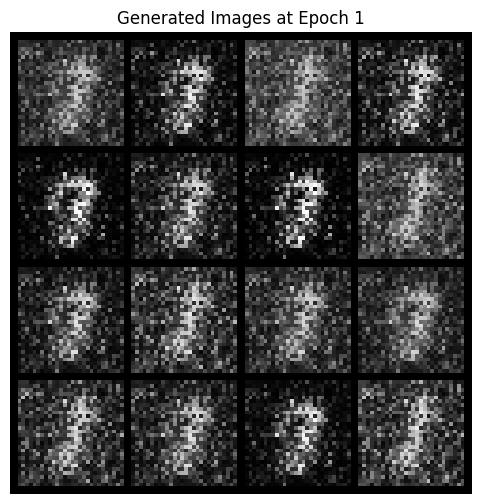

[2/50][0/469] Loss_D: 1.0836 Loss_G: 4.4457
[2/50][200/469] Loss_D: 0.5635 Loss_G: 3.8538
[2/50][400/469] Loss_D: 0.9995 Loss_G: 1.0484
[3/50][0/469] Loss_D: 0.5454 Loss_G: 2.2809
[3/50][200/469] Loss_D: 0.6502 Loss_G: 1.5475
[3/50][400/469] Loss_D: 0.5950 Loss_G: 2.4696
[4/50][0/469] Loss_D: 0.5313 Loss_G: 2.8479
[4/50][200/469] Loss_D: 0.3947 Loss_G: 2.9071
[4/50][400/469] Loss_D: 0.2476 Loss_G: 2.7631
[5/50][0/469] Loss_D: 0.4367 Loss_G: 2.9146
[5/50][200/469] Loss_D: 0.4262 Loss_G: 2.5815
[5/50][400/469] Loss_D: 0.3963 Loss_G: 2.3043
[6/50][0/469] Loss_D: 0.2712 Loss_G: 2.4914
[6/50][200/469] Loss_D: 0.5717 Loss_G: 1.8271
[6/50][400/469] Loss_D: 0.5542 Loss_G: 1.8117
[7/50][0/469] Loss_D: 0.6961 Loss_G: 1.7095
[7/50][200/469] Loss_D: 0.5854 Loss_G: 2.3233
[7/50][400/469] Loss_D: 0.5195 Loss_G: 1.8412
[8/50][0/469] Loss_D: 1.1696 Loss_G: 1.3406
[8/50][200/469] Loss_D: 0.6045 Loss_G: 2.5885
[8/50][400/469] Loss_D: 0.7462 Loss_G: 2.3153
[9/50][0/469] Loss_D: 0.7641 Loss_G: 0.7316
[9/5

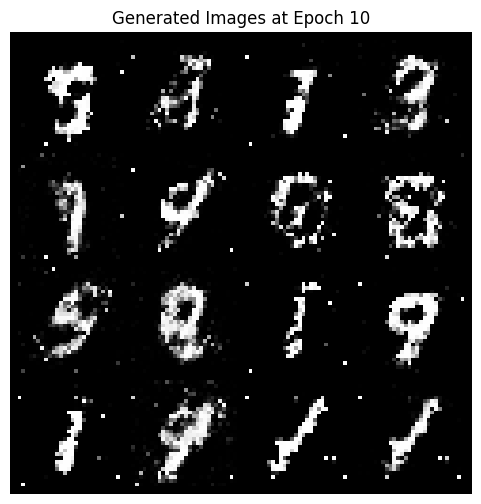

[11/50][0/469] Loss_D: 0.6471 Loss_G: 1.4807
[11/50][200/469] Loss_D: 0.8012 Loss_G: 1.7961
[11/50][400/469] Loss_D: 0.7711 Loss_G: 1.5152
[12/50][0/469] Loss_D: 0.7455 Loss_G: 1.8169
[12/50][200/469] Loss_D: 0.7945 Loss_G: 1.3265
[12/50][400/469] Loss_D: 1.0615 Loss_G: 2.0088
[13/50][0/469] Loss_D: 1.0278 Loss_G: 1.4339
[13/50][200/469] Loss_D: 0.9372 Loss_G: 1.2819
[13/50][400/469] Loss_D: 0.7927 Loss_G: 1.7889
[14/50][0/469] Loss_D: 0.9963 Loss_G: 2.0733
[14/50][200/469] Loss_D: 0.9304 Loss_G: 1.1740
[14/50][400/469] Loss_D: 0.8180 Loss_G: 1.2750
[15/50][0/469] Loss_D: 0.7734 Loss_G: 1.6996
[15/50][200/469] Loss_D: 0.9841 Loss_G: 1.3996
[15/50][400/469] Loss_D: 1.0864 Loss_G: 1.5296
[16/50][0/469] Loss_D: 0.8897 Loss_G: 1.3380
[16/50][200/469] Loss_D: 0.8931 Loss_G: 1.4054
[16/50][400/469] Loss_D: 0.9660 Loss_G: 1.1991
[17/50][0/469] Loss_D: 1.0342 Loss_G: 1.2696
[17/50][200/469] Loss_D: 0.9312 Loss_G: 1.3238
[17/50][400/469] Loss_D: 0.9346 Loss_G: 1.5270
[18/50][0/469] Loss_D: 1.09

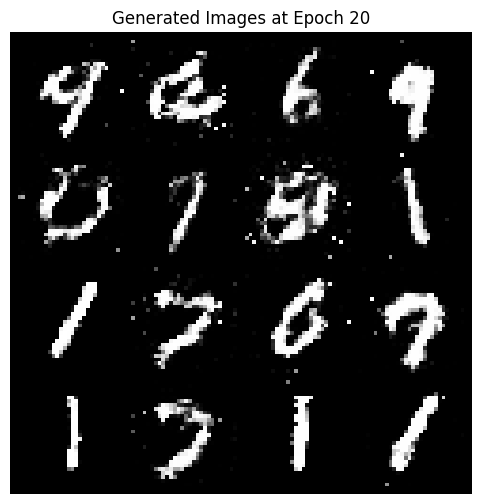

[21/50][0/469] Loss_D: 1.0501 Loss_G: 1.0468
[21/50][200/469] Loss_D: 0.9610 Loss_G: 1.4003
[21/50][400/469] Loss_D: 1.0374 Loss_G: 1.0854
[22/50][0/469] Loss_D: 1.0241 Loss_G: 1.4980
[22/50][200/469] Loss_D: 0.9654 Loss_G: 1.2010
[22/50][400/469] Loss_D: 1.0498 Loss_G: 1.3302
[23/50][0/469] Loss_D: 1.0108 Loss_G: 1.2418
[23/50][200/469] Loss_D: 1.0130 Loss_G: 1.1907
[23/50][400/469] Loss_D: 1.0316 Loss_G: 1.3635
[24/50][0/469] Loss_D: 1.0810 Loss_G: 1.2126
[24/50][200/469] Loss_D: 1.0446 Loss_G: 1.6027
[24/50][400/469] Loss_D: 1.1338 Loss_G: 1.3285
[25/50][0/469] Loss_D: 1.0087 Loss_G: 1.6166
[25/50][200/469] Loss_D: 1.0544 Loss_G: 1.1254
[25/50][400/469] Loss_D: 1.2320 Loss_G: 1.0966
[26/50][0/469] Loss_D: 1.0190 Loss_G: 1.5062
[26/50][200/469] Loss_D: 1.0967 Loss_G: 1.2780
[26/50][400/469] Loss_D: 1.1185 Loss_G: 1.1156
[27/50][0/469] Loss_D: 1.1286 Loss_G: 1.8821
[27/50][200/469] Loss_D: 1.0756 Loss_G: 1.3426
[27/50][400/469] Loss_D: 1.0175 Loss_G: 1.2749
[28/50][0/469] Loss_D: 1.06

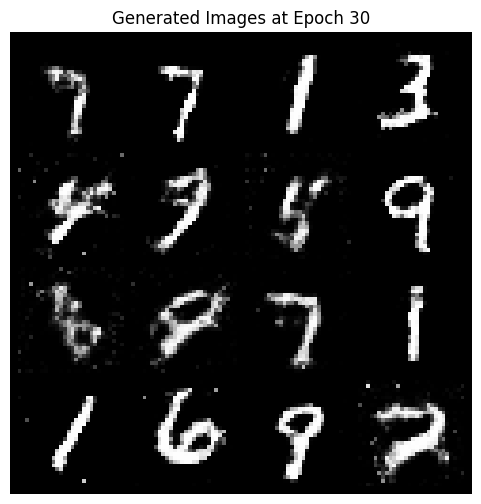

[31/50][0/469] Loss_D: 1.0775 Loss_G: 1.0906
[31/50][200/469] Loss_D: 1.1689 Loss_G: 1.1558
[31/50][400/469] Loss_D: 1.0797 Loss_G: 1.2837
[32/50][0/469] Loss_D: 1.0795 Loss_G: 1.0715
[32/50][200/469] Loss_D: 1.1146 Loss_G: 1.0995
[32/50][400/469] Loss_D: 1.0222 Loss_G: 1.3687
[33/50][0/469] Loss_D: 1.1733 Loss_G: 1.0295
[33/50][200/469] Loss_D: 1.1516 Loss_G: 1.1494
[33/50][400/469] Loss_D: 1.1066 Loss_G: 1.2134
[34/50][0/469] Loss_D: 1.0652 Loss_G: 1.1843
[34/50][200/469] Loss_D: 1.1371 Loss_G: 1.0886
[34/50][400/469] Loss_D: 1.1899 Loss_G: 0.9401
[35/50][0/469] Loss_D: 1.1015 Loss_G: 1.2147
[35/50][200/469] Loss_D: 1.0398 Loss_G: 0.9781
[35/50][400/469] Loss_D: 1.1852 Loss_G: 1.1049
[36/50][0/469] Loss_D: 1.1315 Loss_G: 1.2034
[36/50][200/469] Loss_D: 1.1052 Loss_G: 1.2796
[36/50][400/469] Loss_D: 1.1352 Loss_G: 1.0374
[37/50][0/469] Loss_D: 1.1198 Loss_G: 1.1874
[37/50][200/469] Loss_D: 1.0960 Loss_G: 0.9832
[37/50][400/469] Loss_D: 1.2319 Loss_G: 1.1498
[38/50][0/469] Loss_D: 1.11

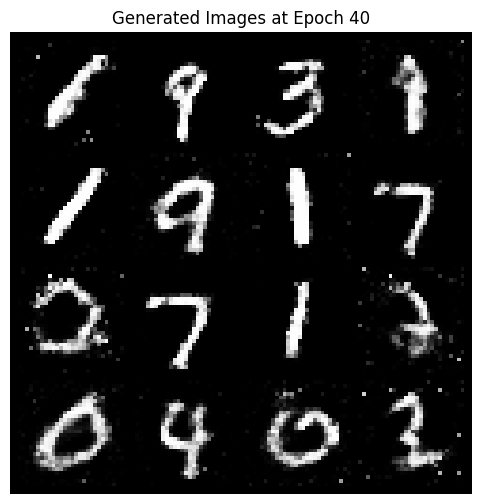

[41/50][0/469] Loss_D: 1.2376 Loss_G: 1.2224
[41/50][200/469] Loss_D: 1.1101 Loss_G: 1.0817
[41/50][400/469] Loss_D: 1.1218 Loss_G: 1.1315
[42/50][0/469] Loss_D: 1.0570 Loss_G: 1.0929
[42/50][200/469] Loss_D: 1.1071 Loss_G: 1.1276
[42/50][400/469] Loss_D: 1.1542 Loss_G: 1.0276
[43/50][0/469] Loss_D: 1.0981 Loss_G: 1.0783
[43/50][200/469] Loss_D: 1.1781 Loss_G: 1.2482
[43/50][400/469] Loss_D: 1.0840 Loss_G: 1.1866
[44/50][0/469] Loss_D: 1.1052 Loss_G: 1.1591
[44/50][200/469] Loss_D: 1.1284 Loss_G: 1.1875
[44/50][400/469] Loss_D: 1.1555 Loss_G: 1.1702
[45/50][0/469] Loss_D: 1.1244 Loss_G: 1.2320
[45/50][200/469] Loss_D: 1.1821 Loss_G: 1.2618
[45/50][400/469] Loss_D: 1.0511 Loss_G: 1.2089
[46/50][0/469] Loss_D: 1.1385 Loss_G: 1.1419
[46/50][200/469] Loss_D: 1.0996 Loss_G: 1.0435
[46/50][400/469] Loss_D: 1.1524 Loss_G: 1.0810
[47/50][0/469] Loss_D: 1.0783 Loss_G: 1.1595
[47/50][200/469] Loss_D: 1.0755 Loss_G: 1.4049
[47/50][400/469] Loss_D: 1.1249 Loss_G: 0.9036
[48/50][0/469] Loss_D: 1.09

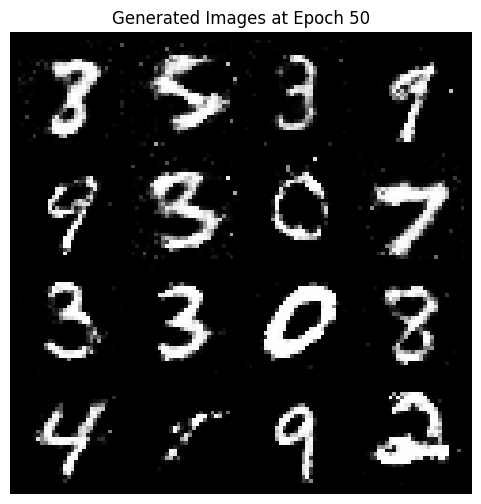

In [7]:
# Lists to store losses for visualization
G_losses = []
D_losses = []

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        
        # ========================================
        # 1. Prepare Real and Fake Data Targets
        # ========================================
        real_imgs = data[0].to(device)
        batch_size_current = real_imgs.size(0)
        
        real_labels = torch.ones(batch_size_current, 1).to(device)
        fake_labels = torch.zeros(batch_size_current, 1).to(device)
        
        # ========================================
        # 2. Train the Discriminator
        # ========================================
        optimizer_D.zero_grad()
        
        # Calculate loss on Real Images
        outputs_real = discriminator(real_imgs)
        d_loss_real = criterion(outputs_real, real_labels)
        
        # Generate random noise and create Fake Images
        z = torch.randn(batch_size_current, latent_size).to(device)
        fake_imgs = generator(z)
        
        # Calculate loss on Fake Images (use .detach() to save memory and avoid training G)
        outputs_fake = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)
        
        # Backpropagate and optimize Discriminator
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # ========================================
        # 3. Train the Generator
        # ========================================
        optimizer_G.zero_grad()
        
        # Pass the fake images to the discriminator again (DO NOT detach this time)
        outputs_fake_for_G = discriminator(fake_imgs)
        
        # The Generator wants the Discriminator to output 1 (real)
        g_loss = criterion(outputs_fake_for_G, real_labels)
        
        # Backpropagate and optimize Generator
        g_loss.backward()
        optimizer_G.step()
        
        # Save Losses
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        
        # Print progress every 200 batches
        if i % 200 == 0:
            print(f"[{epoch+1}/{num_epochs}][{i}/{len(train_loader)}] "
                  f"Loss_D: {d_loss.item():.4f} Loss_G: {g_loss.item():.4f}")
            
    # ========================================
    # 4. Display sample images every few epochs
    # ========================================
    if (epoch + 1) % 10 == 0 or epoch == 0:
        with torch.no_grad(): # Use torch.no_grad() for memory efficiency during inference
            sample_z = torch.randn(16, latent_size).to(device)
            generated_samples = generator(sample_z).cpu()
            
            plt.figure(figsize=(6, 6))
            plt.axis("off")
            plt.title(f"Generated Images at Epoch {epoch+1}")
            grid = torchvision.utils.make_grid(generated_samples, nrow=4, normalize=True)
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.show()

## 8. Save the Models

After training is complete, we save the learned weights (state dictionaries) of both the Generator and the Discriminator to disk. This allows us to load the models later without needing to retrain them.

In [8]:
# Save the trained model parameters
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')
print("Models saved successfully to 'generator.pth' and 'discriminator.pth'")

Models saved successfully to 'generator.pth' and 'discriminator.pth'


## 9. Inference (Generating New Digits)

In this final section, we load our saved Generator model and use it to create new, never-before-seen handwritten digits entirely from random noise.

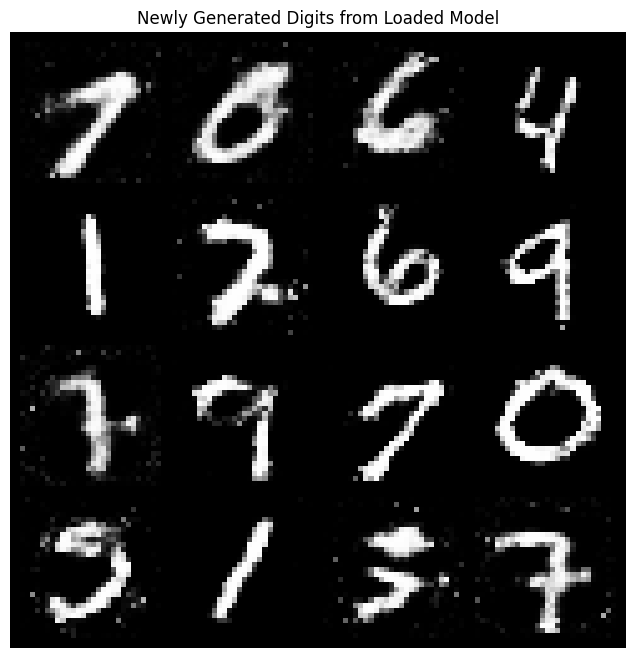

In [9]:
# 1. Initialize a new Generator instance
loaded_generator = Generator(latent_dim=latent_size).to(device)

# 2. Load the saved weights securely
loaded_generator.load_state_dict(torch.load('generator.pth', weights_only=True))

# 3. Set the model to evaluation mode (disables dropout layers)
loaded_generator.eval()

# 4. Generate new images from random noise
with torch.no_grad():
    noise = torch.randn(16, latent_size).to(device)
    new_images = loaded_generator(noise).cpu()

# 5. Display the generated images in a grid
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Newly Generated Digits from Loaded Model")
grid = torchvision.utils.make_grid(new_images, nrow=4, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()

## 10. Loss Visualization

Finally, let's plot the stored loss curves of both models throughout the training process. In an ideal GAN, both losses should somewhat stabilize as the Discriminator and Generator learn to balance each other.

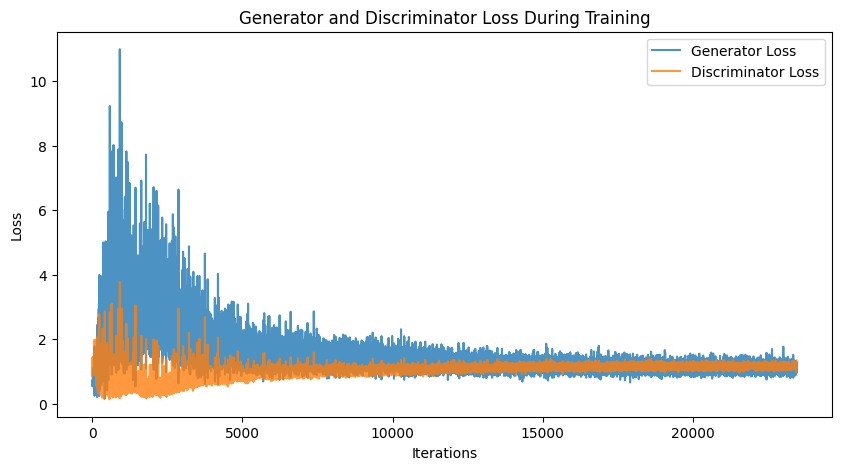

In [10]:
# Plot the training losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator Loss", alpha=0.8)
plt.plot(D_losses, label="Discriminator Loss", alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()